In [6]:
import numpy as np
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

Remember that numpy arrays can be used to hold data that represents images. Here's an example from one of the most famous image datasets in the world, a collection of pictures of hand-written digits (the [MNIST dataset](https://en.wikipedia.org/wiki/MNIST_database)).

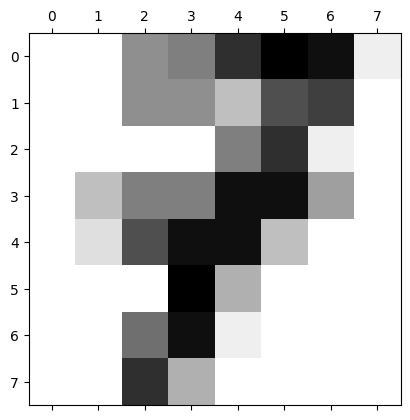

In [64]:
digits = load_digits()
sample_img = digits.images[7]
plt.matshow(sample_img, cmap = "gray_r") # cmap = "gray_r" is for reversing the color map if we want to have white background 

Let's display the array values to remember what this "image" looks like, as represented via numpy.

In [65]:
sample_img

array([[ 0.,  0.,  7.,  8., 13., 16., 15.,  1.],
       [ 0.,  0.,  7.,  7.,  4., 11., 12.,  0.],
       [ 0.,  0.,  0.,  0.,  8., 13.,  1.,  0.],
       [ 0.,  4.,  8.,  8., 15., 15.,  6.,  0.],
       [ 0.,  2., 11., 15., 15.,  4.,  0.,  0.],
       [ 0.,  0.,  0., 16.,  5.,  0.,  0.,  0.],
       [ 0.,  0.,  9., 15.,  1.,  0.,  0.,  0.],
       [ 0.,  0., 13.,  5.,  0.,  0.,  0.,  0.]])

## How is a colormap represented?
The array contains numbers that encode the lightness or darkness of a given pixel value. What is the range of values used in this particular map? 

In [66]:
max_val = np.max(sample_img)
min_val = np.min(sample_img)
midpoint = (max_val + min_val) / 2
print(f"Max: {max_val}, Min: {min_val}, Midpoint: {midpoint}")

Max: 16.0, Min: 0.0, Midpoint: 8.0


## Two-color map
Right now, there are 17 possible values a pixel can take (if this seems a bit unusual, it's an [artifact of how the dataset was created](https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits)). What if we wanted to process an image so it contains _only two_ values- the lightest value and the darkest value? 

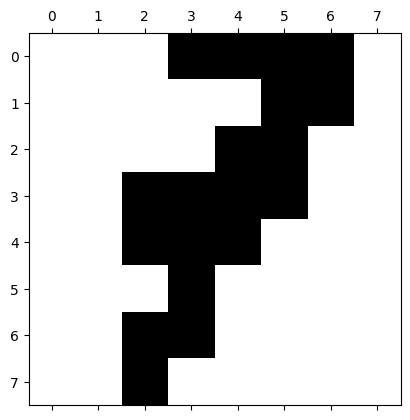

In [67]:
two_value = sample_img.copy()
two_value[two_value < midpoint] = min_val
two_value[two_value >= midpoint] = max_val

# Plot it
plt.matshow(two_value, cmap = "gray_r") # cmap = "gray_r" is for reversing the color map if we want to have white background

## Three-color map
What if instead of only two values in our colormap, we want three? We could split the value range of the original image into three equally-spaced chunks, and then map each chunk to one value. 

In [70]:
# What if we cut it into THREE components?
cutpoint1 = min_val + (max_val - min_val) / 3
cutpoint2 = min_val + 2 * (max_val - min_val) / 3

three_value = sample_img.copy()

In [71]:
three_value[three_value < cutpoint1] = min_val
three_value[three_value > cutpoint2] = max_val
three_value[(three_value > cutpoint1) and (three_value < cutpoint2)] = midpoint

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

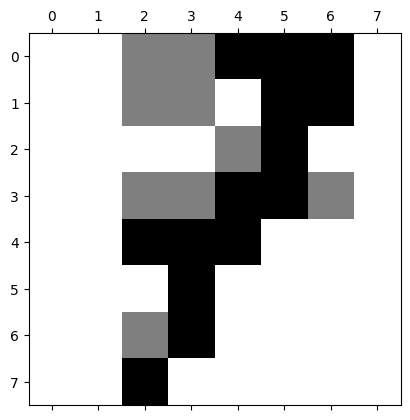

In [63]:
plt.matshow(three_value, cmap = "gray_r") # cmap = "gray_r" is for reversing the color map if we want to have white background